# Proyecto Final — Ciencia de Datos
## Análisis del Tiempo de Espera en Instituciones Médicas de Tijuana

**Integrantes:**
- Sofía Cristina Durán Muñoz [22211752]
- Karla Emilia Silva Pérez [22211767]
- Ana Kamila Valle Z. Flores [22211769]
- María Belén Galindo Ramírez [22211755]

**Departamento de Ingeniería Eléctrica y Electrónica**  
Tecnológico Nacional de México / Instituto Tecnológico de Tijuana

---

**Objetivo:** Predecir si el problema de salud de un paciente fue resuelto satisfactoriamente, considerando el tiempo de espera y otras variables clínicas.

---
## 0. Instalación e importación de librerías

In [ ]:
%pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn --quiet

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, f1_score
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('Librerías listas.')

Librerías listas.


---
## 1. Carga del dataset

In [ ]:
df_raw = pd.read_csv('Dataset_CdD.csv')

# Renombramos columnas a nombres cortos y manejables
df_raw.columns = [
    'timestamp', 'consent', 'nombre', 'sexo', 'edad',
    'institucion', 'motivo', 'especialidad', 'tipo_consulta',
    'diagnostico', 'tiempo_espera', 'tiempo_espera_meses',
    'reagendamientos', 'quien_cancelo', 'desenlace',
    'problema_resuelto', 'fallecimiento'
]

print(f'Dataset cargado: {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas')
display(df_raw.head(3))

FileNotFoundError: [Errno 2] No such file or directory: 'Dataset_CdD.csv'

---
## 2. Exploración inicial (EDA)

In [ ]:
print('--- TIPOS DE DATOS ---')
display(df_raw.dtypes.to_frame(name='dtype'))

print('\n--- VALORES NULOS ---')
nulos = df_raw.isnull().sum()
display(nulos[nulos > 0].to_frame(name='nulos'))

print('\n--- ESTADÍSTICAS DE EDAD ---')
display(df_raw[['edad']].describe())

--- TIPOS DE DATOS ---


,dtype
timestamp,object
consent,object
nombre,object
sexo,object
edad,int64
institucion,object
motivo,object
especialidad,object
tipo_consulta,object
diagnostico,object



--- VALORES NULOS ---


,nulos
tiempo_espera_meses,199



--- ESTADÍSTICAS DE EDAD ---


,edad
count,207.000000
mean,27.444444
std,13.089889
min,0.000000
25%,21.000000
50%,23.000000
75%,26.500000
max,100.000000


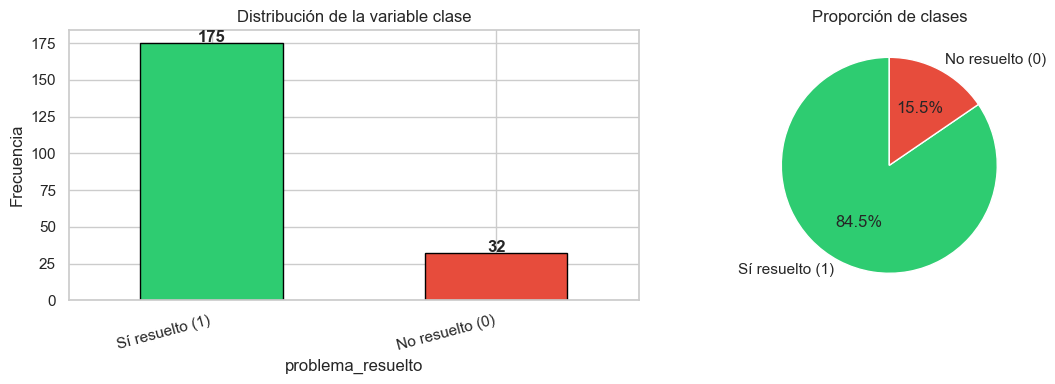

⚠ Desbalance de clases: 175 positivos (84.5%) vs 32 negativos (15.5%)


In [ ]:
# Distribución de la variable clase (target)
conteo = df_raw['problema_resuelto'].value_counts()
etiquetas = ['Sí resuelto (1)', 'No resuelto (0)']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

conteo.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Distribución de la variable clase')
axes[0].set_xticklabels(etiquetas, rotation=15, ha='right')
axes[0].set_ylabel('Frecuencia')
for i, v in enumerate(conteo):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

axes[1].pie(conteo, labels=etiquetas, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()
print(f'⚠ Desbalance de clases: {conteo.iloc[0]} positivos ({conteo.iloc[0]/len(df_raw)*100:.1f}%) vs {conteo.iloc[1]} negativos ({conteo.iloc[1]/len(df_raw)*100:.1f}%)')

### 📊 Interpretación — Distribución de la variable clase

El dataset presenta un **desbalance de clases notable**: de los 207 registros originales, **175 corresponden a "Sí resuelto" (84.5%)** y solo **32 a "No resuelto" (15.5%)**. Esto significa que casi 6 de cada 7 pacientes reportó haber resuelto su problema de salud.

Este desbalance es un factor crítico a considerar en el modelado: un clasificador que predijera siempre "Sí resuelto" alcanzaría un 84.5% de accuracy sin aprender nada útil. Por ello, en la sección 6 se utilizará `class_weight='balanced'` para compensar este efecto.

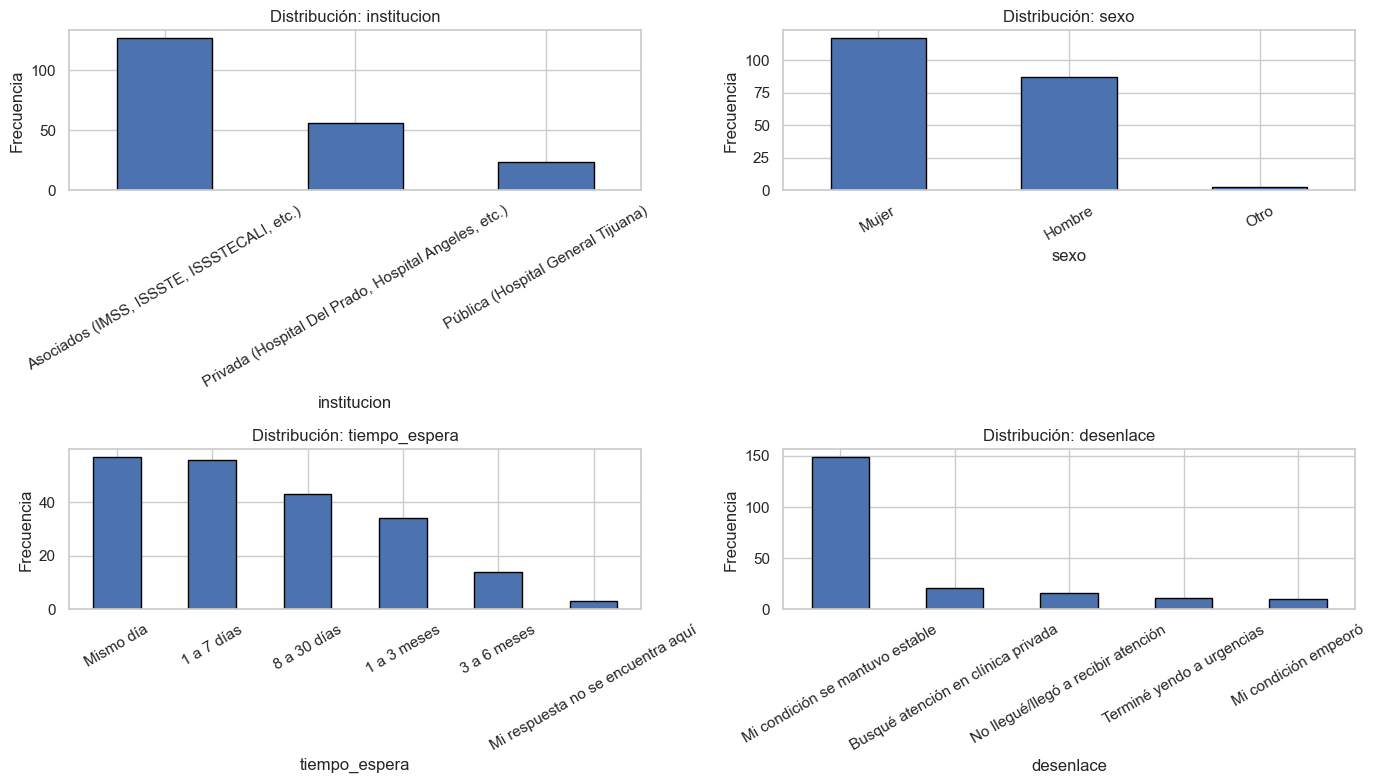

In [ ]:
# Distribución de las principales variables categóricas
vars_graf = ['institucion', 'sexo', 'tiempo_espera', 'desenlace']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

orden_tiempo = ['Mismo día', '1 a 7 días', '8 a 30 días', '1 a 3 meses', '3 a 6 meses', 'Mi respuesta no se encuentra aquí']

for i, col in enumerate(vars_graf):
    if col == 'tiempo_espera':
        data = df_raw[col].value_counts().reindex(orden_tiempo).dropna()
    else:
        data = df_raw[col].value_counts().head(6)
    data.plot(kind='bar', ax=axes[i], edgecolor='black')
    axes[i].set_title(f'Distribución: {col}')
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 📊 Interpretación — Distribución de variables categóricas

- **Institución:** La mayoría de los pacientes pertenecen a instituciones asociadas (IMSS, ISSSTE, ISSSTECALI), seguidas por instituciones privadas y, en menor medida, el Hospital General de Tijuana.
- **Sexo:** Hay una ligera mayoría de mujeres en la muestra, seguidas por hombres. La categoría "Otro" es marginal.
- **Tiempo de espera:** Los tiempos cortos ("Mismo día" y "1 a 7 días") concentran la mayor frecuencia, con una caída progresiva hacia esperas más largas. Esto indica que la mayoría de los pacientes fue atendida de forma relativamente rápida.
- **Desenlace:** La categoría "Mi condición se mantuvo estable" es ampliamente dominante, lo que es consistente con el alto porcentaje de casos "Sí resueltos" visto en la variable objetivo.

---
## 3. Limpieza de datos

### 3.1 Eliminación de la columna `nombre` (confidencialidad)

In [ ]:
df = df_raw.copy()

# Eliminamos la columna de nombres por privacidad
df = df.drop(columns=['nombre'])
print('Columna "nombre" eliminada por confidencialidad.')
print(f'Columnas restantes: {df.columns.tolist()}')

Columna "nombre" eliminada por confidencialidad.
Columnas restantes: ['timestamp', 'consent', 'sexo', 'edad', 'institucion', 'motivo', 'especialidad', 'tipo_consulta', 'diagnostico', 'tiempo_espera', 'tiempo_espera_meses', 'reagendamientos', 'quien_cancelo', 'desenlace', 'problema_resuelto', 'fallecimiento']


### 3.2 Eliminación de registros sin consentimiento

In [ ]:
sin_consentimiento = df[df['consent'].str.strip() != 'Sí']
print(f'Registros sin consentimiento: {len(sin_consentimiento)}')
display(sin_consentimiento[['consent', 'sexo', 'edad']].head())

df = df[df['consent'].str.strip() == 'Sí'].reset_index(drop=True)
df = df.drop(columns=['consent', 'timestamp'])  # ya no se necesitan
print(f'\nTamaño tras eliminar sin consentimiento: {df.shape}')

Registros sin consentimiento: 2


,consent,sexo,edad
9,No,Otro,100
115,No,Hombre,24



Tamaño tras eliminar sin consentimiento: (205, 14)


### 3.3 Eliminación de registros inválidos o de prueba

In [ ]:

# Categorías de motivo válidas (pre y post mapeo de 3.4)
CATEGORIAS_VALIDAS = {
    # Categorías finales (post-mapeo 3.4)
    'Revisión general / chequeo',
    'Lesión o accidente',
    'Seguimiento de tratamiento',
    'Control de enfermedad crónica (diabetes, hipertensión, EPOC, cáncer, etc.)',
    'Síntomas nuevos o agudos',
    'Dolor crónico',
    'Salud mental',
    'Embarazo o ginecología',
    # Valores pre-mapeo que sí son palabras médicas válidas
    'Resfriado',
    'Vacuna',
    'Cardiología',
    'Consulta psicologíca',
}

def limpiar_registros_invalidos(df, col_edad='edad', col_motivo='motivo',
                                edad_min=1, edad_max=110):
    """
    Detecta y elimina registros claramente falsos o de prueba
    sin necesidad de identificar los valores manualmente.

    Criterios automáticos:
      - Edad fuera del rango médicamente plausible (1–110)
      - Motivo con ≤ 2 caracteres (tecleo accidental)
      - Motivo sin ninguna vocal (no es una palabra real)
      - Motivo sin ninguna letra del alfabeto
      - Registro de acompañante (no es el paciente)
      - Motivo fuera de todas las categorías conocidas (ej. 'Chorro')
    """

    # --- Edad fuera de rango ---
    mask_edad = ~df[col_edad].between(edad_min, edad_max)

    # --- Motivo basura por forma ---
    motivo = df[col_motivo].fillna('').str.strip()
    mask_corto   = motivo.str.len() <= 2
    mask_vocales = ~motivo.str.lower().str.contains(r'[aeiouáéíóúü]', na=False)
    mask_no_alfa = ~motivo.str.contains(r'[a-záéíóúüñA-Z]', na=False)

    # --- Acompañante (no es paciente) ---
    mask_acomp = df[col_motivo].str.contains(r'acompañan', na=False, case=False)

    # --- Fuera de categorías conocidas ---
    mask_fuera = ~df[col_motivo].isin(CATEGORIAS_VALIDAS)

    # --- Máscara combinada ---
    mask_total = mask_edad | mask_corto | mask_vocales | mask_no_alfa | mask_acomp | mask_fuera

    # --- Reporte ---
    print('Registros problemáticos detectados (automáticamente):')
    print(f'  - Edad fuera de rango ({edad_min}–{edad_max}): {mask_edad.sum()} registro(s)')
    print(f'  - Motivo muy corto (≤2 chars):           {mask_corto.sum()} registro(s)')
    print(f'  - Motivo sin vocales:                    {mask_vocales.sum()} registro(s)')
    print(f'  - Motivo sin letras:                     {mask_no_alfa.sum()} registro(s)')
    print(f'  - Registro de acompañante:               {mask_acomp.sum()} registro(s)')
    print(f'  - Motivo fuera de categorías válidas:    {mask_fuera.sum()} registro(s)')

    # Muestra qué valores fuera de categoría se detectaron
    fuera_vals = df.loc[mask_fuera, col_motivo].value_counts()
    if not fuera_vals.empty:
        print('    Valores detectados fuera de categoría:')
        for val, cnt in fuera_vals.items():
            print(f'      · "{val}": {cnt} registro(s)')

    print(f'\nTotal a eliminar (sin duplicar): {mask_total.sum()} registros')

    df_limpio = df[~mask_total].reset_index(drop=True)
    print(f'Tamaño tras limpieza: {df_limpio.shape}')

    return df_limpio


df = limpiar_registros_invalidos(df)

Registros problemáticos detectados (automáticamente):
  - Edad fuera de rango (1–110): 1 registro(s)
  - Motivo muy corto (≤2 chars):           1 registro(s)
  - Motivo sin vocales:                    1 registro(s)
  - Motivo sin letras:                     0 registro(s)
  - Registro de acompañante:               1 registro(s)
  - Motivo fuera de categorías válidas:    3 registro(s)
    Valores detectados fuera de categoría:
      · "G": 1 registro(s)
      · "Acompañando": 1 registro(s)
      · "Chorro": 1 registro(s)

Total a eliminar (sin duplicar): 4 registros
Tamaño tras limpieza: (201, 14)


### 3.4 Normalización de variables con texto libre

In [ ]:
# Normalizar motivo de consulta
mapa_motivo = {
    'Resfriado':           'Síntomas nuevos o agudos',
    'Vacuna':              'Revisión general / chequeo',
    'Cardiología':         'Control de enfermedad crónica (diabetes, hipertensión, EPOC, cáncer, etc.)',
    'Consulta psicologíca':'Salud mental',
}
df['motivo'] = df['motivo'].replace(mapa_motivo)

# Normalizar especialidad (texto libre → categoría más cercana)
mapa_especialidad = {
    'Nefropatia':             'Otra',
    'Angiólogo ':             'Otra',
    'Urología y Nefrología':  'Otra',
    'Cirugía':                'Otra',
    'medicina critica':       'Otra',
    'Otorrinolaringológía':   'Otra',
    'Otorrinolaringólogo':    'Otra',
    'Internista':             'Otra',
    'Traumatologo':           'Ortopedia / traumatología',
    'Geriatría':              'Otra',
    'Urgencias':              'Otra',
    'Reumatólogo':            'Otra',
    'Radiología':             'Otra',
    'G':                      'Otra',
}
df['especialidad'] = df['especialidad'].replace(mapa_especialidad)

# Manejo de la columna tiempo_espera_meses (solo 8 valores válidos)
# La descartamos porque ya está codificada en tiempo_espera
df = df.drop(columns=['tiempo_espera_meses'])

print('Normalización completada.')
print(f'Columnas actuales: {df.columns.tolist()}')

Normalización completada.
Columnas actuales: ['sexo', 'edad', 'institucion', 'motivo', 'especialidad', 'tipo_consulta', 'diagnostico', 'tiempo_espera', 'reagendamientos', 'quien_cancelo', 'desenlace', 'problema_resuelto', 'fallecimiento']


### 3.5 Verificación de inconsistencias biológicas

In [ ]:
# Inconsistencia: Hombre + diagnóstico de embarazo
hombre_embarazo = df[
    (df['sexo'] == 'Hombre') &
    (df['diagnostico'].str.contains('Embarazo|embarazo', na=False))
]
print(f'Hombre + Embarazo: {len(hombre_embarazo)} caso(s) — ', end='')
print('✓ Sin inconsistencias' if len(hombre_embarazo) == 0 else '⚠ Revisar')

# Inconsistencia: problema resuelto = Sí pero hubo fallecimiento
fallecio_resuelto = df[
    (df['fallecimiento'] != 'No aplica') &
    (df['problema_resuelto'].str.startswith('Sí'))
]
print(f'\nFallecimiento + Problema resuelto = Sí: {len(fallecio_resuelto)} caso(s)')
if len(fallecio_resuelto) > 0:
    display(fallecio_resuelto[['sexo', 'edad', 'fallecimiento', 'problema_resuelto']].head())
    print('  → Se corregirá: si hubo fallecimiento, problema_resuelto = 0')
    idx = fallecio_resuelto.index
    df.loc[idx, 'problema_resuelto'] = 'No — sin diagnóstico claro, sin mejoría o se buscó otra atención'
    print('  ✓ Corrección aplicada.')

Hombre + Embarazo: 0 caso(s) — ✓ Sin inconsistencias

Fallecimiento + Problema resuelto = Sí: 12 caso(s)


,sexo,edad,fallecimiento,problema_resuelto
17,Mujer,22,Fuera del hospital,"Sí — se recibió diagnóstico, tratamiento y se ..."
44,Mujer,23,Esperaba una cita programada/agendada,"Sí — se recibió diagnóstico, tratamiento y se ..."
100,Hombre,16,Esperaba una cita programada/agendada,"Sí — se recibió diagnóstico, tratamiento y se ..."
110,Hombre,25,Aun siendo recibido el tratamiento,"Sí — se recibió diagnóstico, tratamiento y se ..."
113,Hombre,28,Fuera del hospital,"Sí — se recibió diagnóstico, tratamiento y se ..."


  → Se corregirá: si hubo fallecimiento, problema_resuelto = 0
  ✓ Corrección aplicada.


### 3.6 Estado del dataset limpio

In [ ]:
print('=== RESUMEN DEL DATASET LIMPIO ===')
print(f'Filas:    {df.shape[0]}')
print(f'Columnas: {df.shape[1]}')
print(f'Nulos:    {df.isnull().sum().sum()}')
print()
print('--- Distribución final de la clase ---')
print(df['problema_resuelto'].value_counts())
display(df.head(3))

=== RESUMEN DEL DATASET LIMPIO ===
Filas:    201
Columnas: 13
Nulos:    0

--- Distribución final de la clase ---
problema_resuelto
Sí — se recibió diagnóstico, tratamiento y se mejoró                160
No — sin diagnóstico claro, sin mejoría o se buscó otra atención     41
Name: count, dtype: int64


,sexo,edad,institucion,motivo,especialidad,tipo_consulta,diagnostico,tiempo_espera,reagendamientos,quien_cancelo,desenlace,problema_resuelto,fallecimiento
0,Mujer,23,"Asociados (IMSS, ISSSTE, ISSSTECALI, etc.)",Revisión general / chequeo,Medicina general / familiar,Subsecuente/seguimiento,Sin diagnóstico al momento,1 a 3 meses,Ninguna vez,No aplica,Mi condición se mantuvo estable,"No — sin diagnóstico claro, sin mejoría o se b...",No aplica
1,Mujer,23,"Privada (Hospital Del Prado, Hospital Angeles,...",Dolor crónico,Medicina general / familiar,Primera vez,"Enfermedad respiratoria (ej. asma, bronquitis,...",1 a 7 días,Ninguna vez,Yo mismo/a (el paciente),Mi condición se mantuvo estable,"Sí — se recibió diagnóstico, tratamiento y se ...",No aplica
2,Mujer,46,"Asociados (IMSS, ISSSTE, ISSSTECALI, etc.)","Control de enfermedad crónica (diabetes, hiper...",Medicina general / familiar,Subsecuente/seguimiento,Hipertensión arterial (presión arterial alta),1 a 3 meses,Ninguna vez,No aplica,Mi condición se mantuvo estable,"Sí — se recibió diagnóstico, tratamiento y se ...",No aplica


---
## 4. Análisis Exploratorio de Relaciones Clave
### 4.1 Institución vs Tiempo de espera

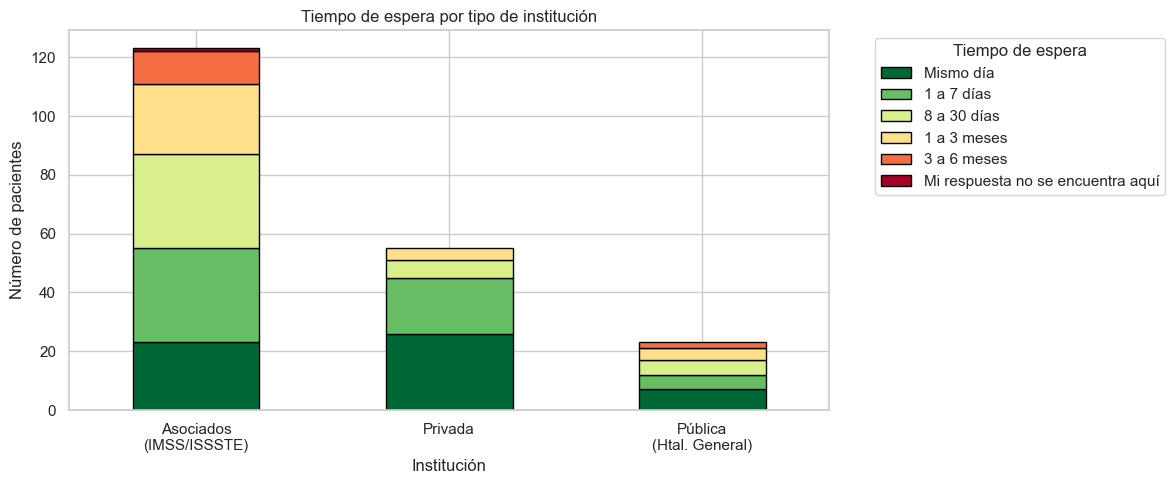

In [ ]:
orden_tiempo = ['Mismo día', '1 a 7 días', '8 a 30 días', '1 a 3 meses', '3 a 6 meses', 'Mi respuesta no se encuentra aquí']

ct = pd.crosstab(df['institucion'], df['tiempo_espera'])
ct = ct.reindex(columns=[c for c in orden_tiempo if c in ct.columns])

# Acortamos etiquetas de institución para la gráfica
ct.index = ['Asociados\n(IMSS/ISSSTE)', 'Privada', 'Pública\n(Htal. General)']

ct.plot(kind='bar', stacked=True, figsize=(12, 5), colormap='RdYlGn_r', edgecolor='black')
plt.title('Tiempo de espera por tipo de institución')
plt.ylabel('Número de pacientes')
plt.xlabel('Institución')
plt.xticks(rotation=0)
plt.legend(title='Tiempo de espera', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 📊 Interpretación — Institución vs Tiempo de espera

La gráfica revela diferencias estructurales claras entre instituciones. Las instituciones **asociadas (IMSS/ISSSTE)** concentran la mayor cantidad de pacientes en general, pero también acumulan la mayor proporción de esperas largas: la franja amarilla (1 a 3 meses) es visible y las categorías naranja/roja (3 a 6 meses y sin respuesta) aparecen únicamente en este grupo.

Las instituciones **privadas** muestran un perfil más favorable: la mayoría de sus pacientes fue atendida en menos de 7 días (franjas verdes dominantes), y prácticamente no tienen esperas de más de un mes.

El **Hospital General de Tijuana** (pública) atiende al menor número de pacientes del conjunto, con tiempos de espera distribuidos entre todas las categorías, lo que refleja una demanda más contenida pero con variabilidad en la oportunidad de atención.

### 4.2 Tiempo de espera vs Problema resuelto

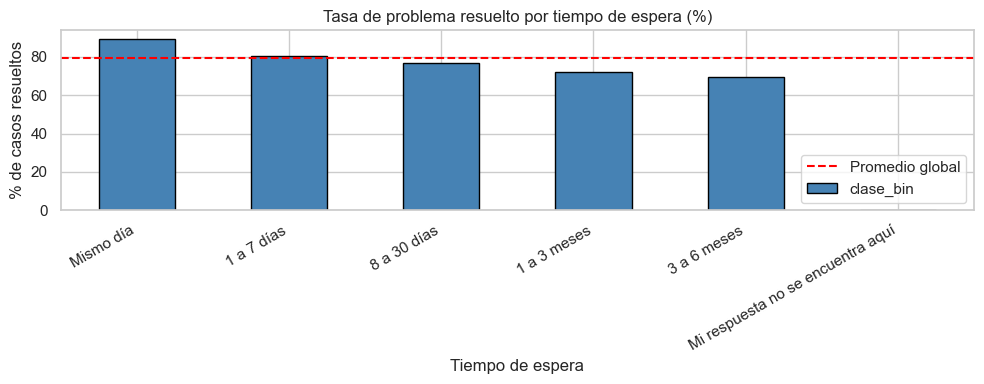

In [ ]:
df['clase_bin'] = df['problema_resuelto'].apply(lambda x: 1 if str(x).startswith('Sí') else 0)

tasa = df.groupby('tiempo_espera')['clase_bin'].mean().reindex(orden_tiempo).dropna() * 100

tasa.plot(kind='bar', color='steelblue', edgecolor='black', figsize=(10, 4))
plt.title('Tasa de problema resuelto por tiempo de espera (%)')
plt.ylabel('% de casos resueltos')
plt.xlabel('Tiempo de espera')
plt.xticks(rotation=30, ha='right')
plt.axhline(df['clase_bin'].mean()*100, color='red', linestyle='--', label='Promedio global')
plt.legend()
plt.tight_layout()
plt.show()

### 📊 Interpretación — Tiempo de espera vs Problema resuelto

La tasa de resolución disminuye conforme aumenta el tiempo de espera, aunque la relación no es perfectamente lineal. Los pacientes atendidos el **mismo día** tienen la tasa más alta de problema resuelto, superando el promedio global (línea roja punteada). A partir de "1 a 7 días", la tasa cae y se mantiene por debajo del promedio.

El grupo de **"3 a 6 meses"** presenta la tasa más baja de resolución, lo que sugiere que esperas en ese rango son particularmente críticas, posiblemente porque corresponden a padecimientos que se deterioran si no se tratan oportunamente. Esta tendencia refuerza la hipótesis de que el tiempo de espera es una variable predictora relevante para el desenlace del paciente.

### 4.3 Institución vs Desenlace grave

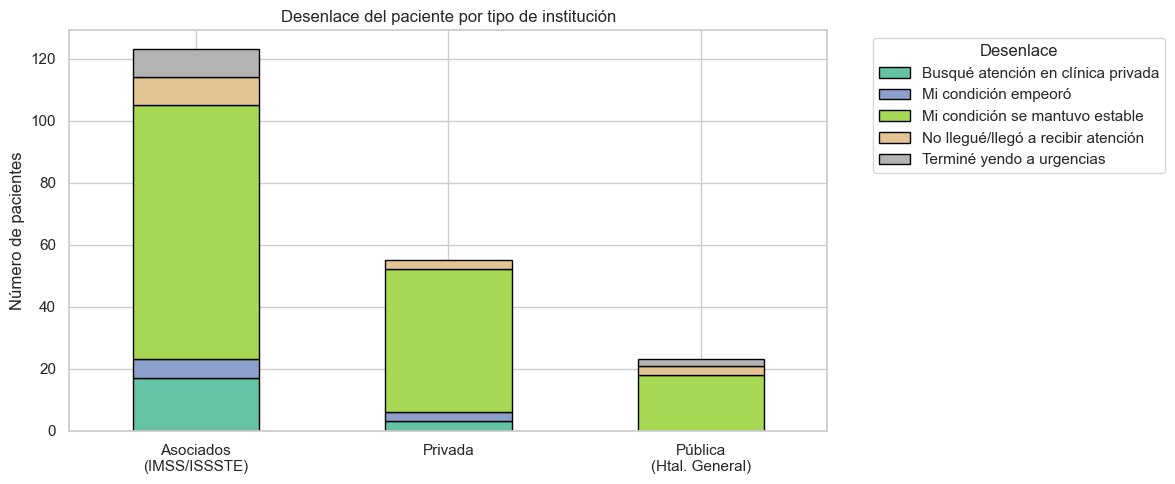

In [ ]:
df['desenlace_grave'] = df['desenlace'].isin([
    'Terminé yendo a urgencias', 'Mi condición empeoró', 'Busqué atención en clínica privada'
]).astype(int)

ct2 = pd.crosstab(df['institucion'], df['desenlace'])
ct2.index = ['Asociados\n(IMSS/ISSSTE)', 'Privada', 'Pública\n(Htal. General)']

ct2.plot(kind='bar', stacked=True, colormap='Set2', edgecolor='black', figsize=(12, 5))
plt.title('Desenlace del paciente por tipo de institución')
plt.ylabel('Número de pacientes')
plt.xticks(rotation=0)
plt.legend(title='Desenlace', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 📊 Interpretación — Institución vs Desenlace grave

En las tres instituciones, el desenlace más frecuente es "Mi condición se mantuvo estable" (verde claro), pero la proporción de desenlaces desfavorables varía significativamente. En las instituciones **asociadas (IMSS/ISSSTE)**, las franjas correspondientes a "Busqué atención en clínica privada", "No llegué a recibir atención" y "Terminé yendo a urgencias" son más visibles, indicando una mayor frecuencia de desenlaces graves o de búsqueda de atención alternativa.

En instituciones **privadas**, casi la totalidad de los casos corresponde a la categoría estable, con muy poca presencia de desenlaces negativos, lo que es consistente con sus menores tiempos de espera observados en la sección 4.1.

### 4.4 Distribución de edades por sexo

C:\Users\HP VICTUS\AppData\Local\Temp\ipykernel_20820\1422441466.py:13: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\HP VICTUS\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


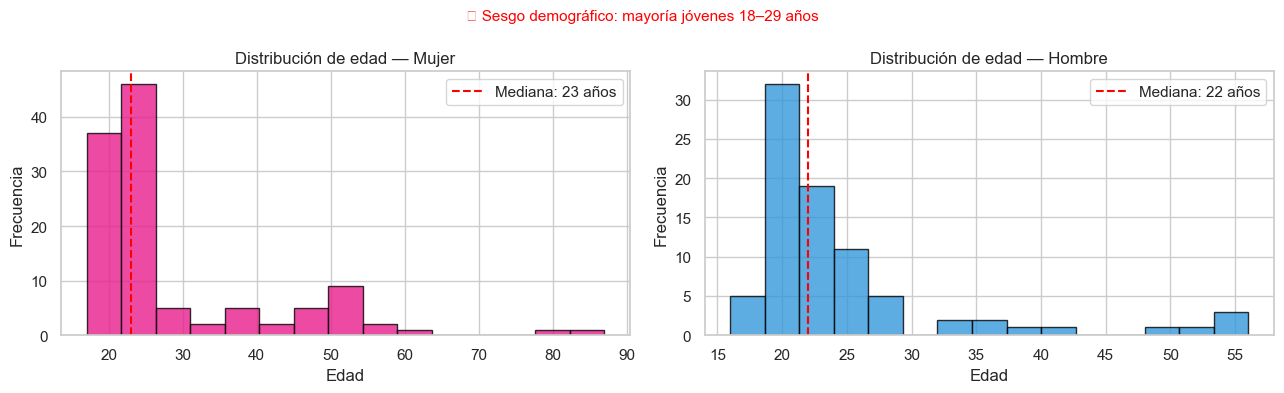

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for sexo, ax in zip(['Mujer', 'Hombre'], axes):
    subset = df[df['sexo'] == sexo]['edad']
    ax.hist(subset, bins=15, edgecolor='black', color='#3498db' if sexo == 'Hombre' else '#e91e8c', alpha=0.8)
    ax.set_title(f'Distribución de edad — {sexo}')
    ax.set_xlabel('Edad')
    ax.set_ylabel('Frecuencia')
    ax.axvline(subset.median(), color='red', linestyle='--', label=f'Mediana: {subset.median():.0f} años')
    ax.legend()

plt.suptitle('⚠ Sesgo demográfico: mayoría jóvenes 18–29 años', fontsize=11, color='red')
plt.tight_layout()
plt.show()

### 📊 Interpretación — Distribución de edades por sexo

Ambos histogramas confirman el **sesgo demográfico juvenil** de la muestra. La mediana de edad es **23 años para mujeres** y **22 años para hombres**, con la gran mayoría de registros concentrados entre los 18 y 29 años. Este patrón es esperable dado que el formulario fue difundido principalmente en entorno universitario.

Se observa una cola hacia edades mayores en el grupo de mujeres (con algunos registros hasta los 85 años), mientras que los hombres muestran una distribución más compacta. La escasa representación de adultos mayores de 40 años limita la capacidad de los modelos para generalizar a poblaciones más vulnerables, que son precisamente las que más utilizan el sistema de salud.

---
## 5. Preprocesamiento para el modelo de clasificación
### 5.1 Selección de variables predictoras

In [ ]:
# Variables que usaremos como predictores
# Excluimos: desenlace_grave, clase_bin (derivadas), fallecimiento (posterior al evento)
COLUMNAS_X = [
    'sexo', 'edad', 'institucion', 'motivo', 'especialidad',
    'tipo_consulta', 'tiempo_espera', 'reagendamientos', 'quien_cancelo'
]
COLUMNA_Y = 'clase_bin'

X_raw = df[COLUMNAS_X].copy()
y = df[COLUMNA_Y].copy()

print('Variables predictoras seleccionadas:')
for c in COLUMNAS_X:
    tipo = 'numérica' if c == 'edad' else 'ordinal' if c in ['tiempo_espera', 'reagendamientos'] else 'categórica'
    print(f'  {c:20s} → {tipo}')
print(f'\nVariable objetivo: {COLUMNA_Y}')
print(f'Distribución: {y.value_counts().to_dict()}')

Variables predictoras seleccionadas:
  sexo                 → categórica
  edad                 → numérica
  institucion          → categórica
  motivo               → categórica
  especialidad         → categórica
  tipo_consulta        → categórica
  tiempo_espera        → ordinal
  reagendamientos      → ordinal
  quien_cancelo        → categórica

Variable objetivo: clase_bin
Distribución: {1: 160, 0: 41}


### 5.2 Codificación de variables categóricas

In [ ]:
X = X_raw.copy()

# --- Variable ordinal: tiempo_espera ---
# Codificamos con orden lógico (más espera = número mayor)
orden_espera = {
    'Mismo día':                             0,
    '1 a 7 días':                            1,
    '8 a 30 días':                           2,
    '1 a 3 meses':                           3,
    '3 a 6 meses':                           4,
    'Mi respuesta no se encuentra aquí':     5,
}
X['tiempo_espera'] = X['tiempo_espera'].map(orden_espera)

# --- Variable ordinal: reagendamientos ---
orden_reagend = {
    'Ninguna vez':   0,
    '1 vez':         1,
    '2 veces':       2,
    '3 veces':       3,
    '4 o más veces': 4,
}
X['reagendamientos'] = X['reagendamientos'].map(orden_reagend)

# --- Variables nominales: One-Hot Encoding ---
cols_ohe = ['sexo', 'institucion', 'motivo', 'especialidad', 'tipo_consulta', 'quien_cancelo']
X = pd.get_dummies(X, columns=cols_ohe, drop_first=False)

print(f'Dimensiones tras codificación: {X.shape}')
print(f'Columnas generadas: {X.shape[1]}')
display(X.head(2))

Dimensiones tras codificación: (201, 42)
Columnas generadas: 42


,edad,tiempo_espera,reagendamientos,sexo_Hombre,sexo_Mujer,sexo_Otro,"institucion_Asociados (IMSS, ISSSTE, ISSSTECALI, etc.)","institucion_Privada (Hospital Del Prado, Hospital Angeles, etc.)",institucion_Pública (Hospital General Tijuana),"motivo_Control de enfermedad crónica (diabetes, hipertensión, EPOC, cáncer, etc.)",...,especialidad_Pediatría,especialidad_Psicología / psiquiatría,especialidad_Radiología,especialidad_Reumatólogo,tipo_consulta_Primera vez,tipo_consulta_Subsecuente/seguimiento,quien_cancelo_Ambos en distintas ocasiones,quien_cancelo_La institución / hospital,quien_cancelo_No aplica,quien_cancelo_Yo mismo/a (el paciente)
0,23,3,0,False,True,False,True,False,False,False,...,False,False,False,False,False,True,False,False,True,False
1,23,1,0,False,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True


### 📊 Interpretación — Codificación de variables

Tras aplicar la codificación ordinal a `tiempo_espera` y `reagendamientos`, y One-Hot Encoding a las variables nominales, el dataset pasó de **9 variables originales a 42 columnas**. Este aumento se debe principalmente a la expansión de variables categóricas con múltiples categorías como `especialidad`, `motivo` e `institucion`.

Es importante notar que con 201 registros y 42 variables, la relación observaciones/variables es relativamente baja (~4.8:1), lo que puede favorecer el sobreajuste en modelos complejos y justifica el uso de `max_depth` como parámetro de control en los clasificadores.

### 5.3 Escalamiento de variables numéricas

In [ ]:
from sklearn.preprocessing import StandardScaler

# Solo escalamos las columnas verdaderamente numéricas
cols_escalar = ['edad', 'tiempo_espera', 'reagendamientos']

scaler = StandardScaler()
X[cols_escalar] = scaler.fit_transform(X[cols_escalar])

print('Variables escaladas (StandardScaler):')
display(X[cols_escalar].describe().round(3))

Variables escaladas (StandardScaler):


,edad,tiempo_espera,reagendamientos
count,201.000,201.000,201.000
mean,0.000,-0.000,0.000
std,1.002,1.002,1.002
min,-0.946,-1.170,-0.596
25%,-0.515,-1.170,-0.596
50%,-0.343,-0.373,-0.596
75%,-0.085,0.425,0.446
max,5.167,2.817,3.571


### 📊 Interpretación — Escalamiento de variables numéricas

El `StandardScaler` transformó las tres variables numéricas para que tengan **media 0 y desviación estándar ~1**, como confirma la tabla de estadísticos. Esto es necesario para que diferencias en escala entre variables (por ejemplo, `edad` en decenas vs. `reagendamientos` en unidades del 0 al 4) no distorsionen los cálculos internos de los modelos.

Los valores extremos observados en `edad` (max = 5.167) y `tiempo_espera` (max = 2.817) corresponden a los casos más alejados de la media en la distribución original, y su presencia después del escalamiento indica que no fueron eliminados como outliers, lo cual es correcto dado que son valores médicamente plausibles.

### 5.4 División entrenamiento / prueba

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # Mantiene proporción de clases en ambos conjuntos
)

print(f'Entrenamiento: {X_train.shape[0]} registros')
print(f'Prueba:        {X_test.shape[0]} registros')
print(f'\nDistribución en entrenamiento:\n{y_train.value_counts()}')
print(f'\nDistribución en prueba:\n{y_test.value_counts()}')

Entrenamiento: 160 registros
Prueba:        41 registros

Distribución en entrenamiento:
clase_bin
1    127
0     33
Name: count, dtype: int64

Distribución en prueba:
clase_bin
1    33
0     8
Name: count, dtype: int64


### 📊 Interpretación — División entrenamiento / prueba

El dataset se dividió en **160 registros para entrenamiento (80%)** y **41 para prueba (20%)**. Gracias al parámetro `stratify=y`, la proporción de clases se preservó en ambos conjuntos:

- **Entrenamiento:** 127 casos "Sí resuelto" (79.4%) y 33 "No resuelto" (20.6%)
- **Prueba:** 33 casos "Sí resuelto" (80.5%) y 8 "No resuelto" (19.5%)

Esta estratificación es fundamental para evitar que el conjunto de prueba quede con una distribución de clases muy diferente al de entrenamiento, lo que podría sesgar las métricas de evaluación.

---
## 6. Modelos de Clasificación
### 6.1 Árbol de Decisión

In [ ]:
modelo_arbol = DecisionTreeClassifier(
    max_depth=5,
    class_weight='balanced',  # Compensa el desbalance de clases
    random_state=42
)
modelo_arbol.fit(X_train, y_train)
y_pred_arbol = modelo_arbol.predict(X_test)

acc_arbol = accuracy_score(y_test, y_pred_arbol)
f1_arbol  = f1_score(y_test, y_pred_arbol, average='weighted')

print(f'Accuracy del Árbol de Decisión: {acc_arbol:.4f}')
print(f'F1-Score (weighted):            {f1_arbol:.4f}')
print()
print('--- Reporte de clasificación ---')
print(classification_report(y_test, y_pred_arbol, target_names=['No resuelto (0)', 'Sí resuelto (1)']))

Accuracy del Árbol de Decisión: 0.6098
F1-Score (weighted):            0.6479

--- Reporte de clasificación ---
                 precision    recall  f1-score   support

No resuelto (0)       0.25      0.50      0.33         8
Sí resuelto (1)       0.84      0.64      0.72        33

       accuracy                           0.61        41
      macro avg       0.54      0.57      0.53        41
   weighted avg       0.72      0.61      0.65        41



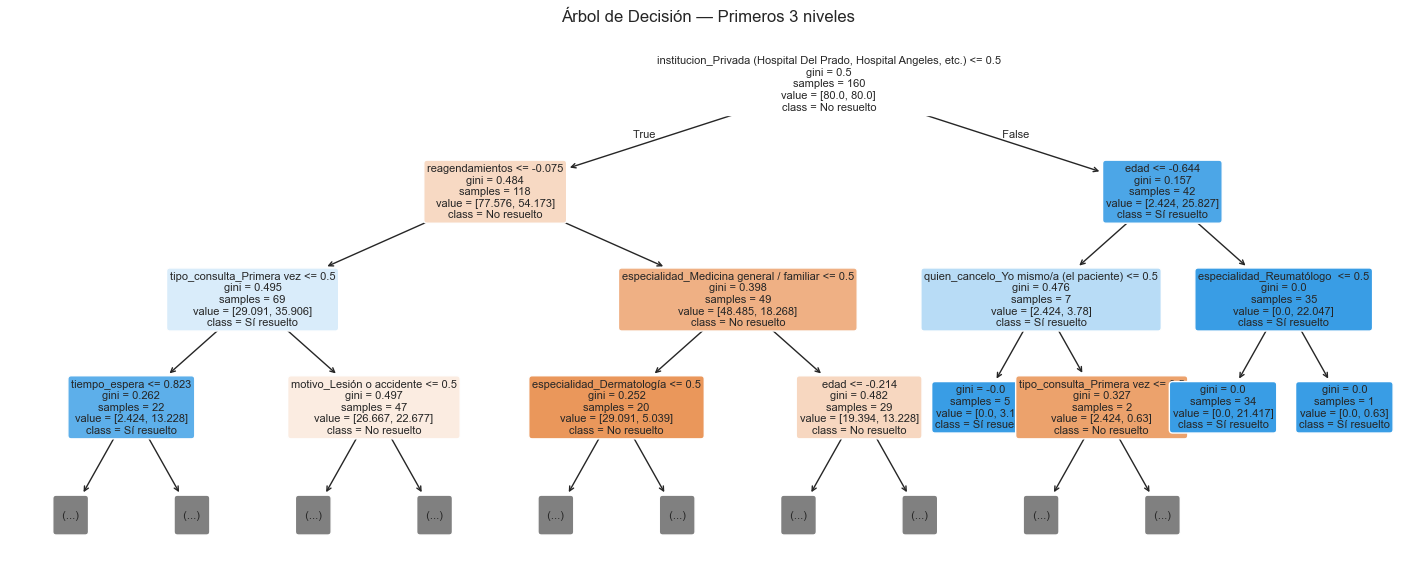

In [ ]:
# Visualización del árbol (simplificado)
plt.figure(figsize=(18, 7))
plot_tree(
    modelo_arbol,
    filled=True,
    feature_names=X.columns.tolist(),
    class_names=['No resuelto', 'Sí resuelto'],
    fontsize=8,
    rounded=True,
    max_depth=3  # Mostramos solo los primeros 3 niveles para legibilidad
)
plt.title('Árbol de Decisión — Primeros 3 niveles')
plt.show()

### 📊 Interpretación — Árbol de Decisión

El Árbol de Decisión obtuvo un **Accuracy de 60.98%** y un **F1-Score ponderado de 0.6479**. En el reporte por clase se observa que el modelo identifica razonablemente bien los casos "Sí resuelto" (recall 0.64, f1 0.72), pero tiene dificultades importantes con la clase minoritaria "No resuelto" (recall 0.50, f1 0.33), lo que indica que falla en detectar la mitad de los casos no resueltos.

La visualización del árbol muestra que la **primera variable de corte es `institucion_Privada`**, lo que confirma que el tipo de institución es el factor más discriminante desde el primer nivel. Cuando el paciente no proviene de una institución privada, el árbol evalúa a continuación el número de `reagendamientos`, y luego el `tipo_consulta` y la `especialidad`. Esto es consistente con el análisis exploratorio de la sección 4.

### 6.2 Naive Bayes

In [ ]:
modelo_nb = GaussianNB()
modelo_nb.fit(X_train, y_train)
y_pred_nb = modelo_nb.predict(X_test)

acc_nb = accuracy_score(y_test, y_pred_nb)
f1_nb  = f1_score(y_test, y_pred_nb, average='weighted')

print(f'Accuracy de Naive Bayes: {acc_nb:.4f}')
print(f'F1-Score (weighted):     {f1_nb:.4f}')
print()
print('--- Reporte de clasificación ---')
print(classification_report(y_test, y_pred_nb, target_names=['No resuelto (0)', 'Sí resuelto (1)']))

Accuracy de Naive Bayes: 0.3902
F1-Score (weighted):     0.3902

--- Reporte de clasificación ---
                 precision    recall  f1-score   support

No resuelto (0)       0.24      1.00      0.39         8
Sí resuelto (1)       1.00      0.24      0.39        33

       accuracy                           0.39        41
      macro avg       0.62      0.62      0.39        41
   weighted avg       0.85      0.39      0.39        41



### 📊 Interpretación — Naive Bayes

Naive Bayes obtuvo el **peor desempeño de los tres modelos**, con un **Accuracy de 39.02%** y un **F1-Score ponderado de 0.3902**. El reporte de clasificación revela el problema central: el modelo clasificó **todos los casos de prueba como "No resuelto"** (recall de 1.00 para la clase 0, pero recall de solo 0.24 para la clase 1), lo que significa que prácticamente ignoró la clase mayoritaria.

Este comportamiento es atípico e indica que el supuesto de independencia entre variables de Naive Bayes no se cumple en este dataset. Variables como `institucion`, `tiempo_espera` y `desenlace` están correlacionadas entre sí, lo que viola el fundamento teórico del modelo y produce predicciones poco confiables.

### 6.3 Random Forest

In [ ]:
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=7,
    class_weight='balanced',
    random_state=42
)
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf  = f1_score(y_test, y_pred_rf, average='weighted')

print(f'Accuracy de Random Forest: {acc_rf:.4f}')
print(f'F1-Score (weighted):       {f1_rf:.4f}')
print()
print('--- Reporte de clasificación ---')
print(classification_report(y_test, y_pred_rf, target_names=['No resuelto (0)', 'Sí resuelto (1)']))

Accuracy de Random Forest: 0.8293
F1-Score (weighted):       0.7965

--- Reporte de clasificación ---
                 precision    recall  f1-score   support

No resuelto (0)       0.67      0.25      0.36         8
Sí resuelto (1)       0.84      0.97      0.90        33

       accuracy                           0.83        41
      macro avg       0.75      0.61      0.63        41
   weighted avg       0.81      0.83      0.80        41



### 📊 Interpretación — Random Forest

Random Forest fue el **mejor modelo de los tres**, con un **Accuracy de 82.93%** y un **F1-Score ponderado de 0.7965**. Para la clase "Sí resuelto" el desempeño es muy sólido (precision 0.84, recall 0.97, f1 0.90), lo que indica que el modelo identifica correctamente casi todos los casos resueltos.

La clase "No resuelto" sigue siendo el reto más difícil: con un recall de 0.25, el modelo solo detecta 2 de los 8 casos negativos reales en el conjunto de prueba. Esto es inherente al desbalance de clases y al tamaño reducido de la muestra. Aun así, Random Forest mejora notablemente al Árbol de Decisión y Naive Bayes, gracias a su capacidad de combinar múltiples árboles y reducir la varianza.

### 6.4 Matrices de confusión — comparativa

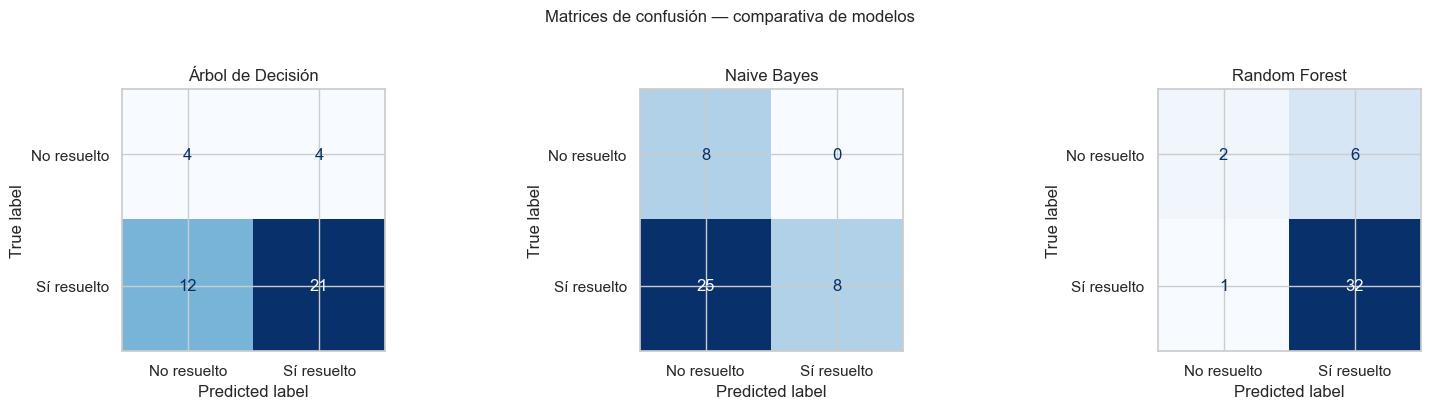

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

modelos_info = [
    ('Árbol de Decisión', y_pred_arbol),
    ('Naive Bayes',       y_pred_nb),
    ('Random Forest',     y_pred_rf),
]

for ax, (nombre, y_pred) in zip(axes, modelos_info):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No resuelto', 'Sí resuelto'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(nombre)

plt.suptitle('Matrices de confusión — comparativa de modelos', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### 📊 Interpretación — Matrices de confusión

Las matrices permiten comparar visualmente los tres modelos sobre el mismo conjunto de prueba (41 registros: 8 negativos y 33 positivos):

- **Árbol de Decisión:** Detecta 4 de 8 negativos correctamente (50% recall), pero clasifica erróneamente 12 positivos como negativos (falsos negativos).
- **Naive Bayes:** Detecta los 8 negativos (100% recall), pero clasifica 25 de 33 positivos como negativos — su alta tasa de falsos negativos para la clase positiva explica su bajo accuracy general.
- **Random Forest:** Solo detecta 2 de 8 negativos, pero comete apenas 1 falso negativo en la clase positiva, logrando el mayor número de verdaderos positivos (32 de 33). Es el modelo más equilibrado para el contexto de este dataset.

---
## 7. Comparativa de modelos y conclusiones
### 7.1 Tabla comparativa de métricas

,Modelo,Accuracy,F1-Score (weighted)
0,Random Forest,0.8293,0.7965
1,Árbol de Decisión,0.6098,0.6479
2,Naive Bayes,0.3902,0.3902


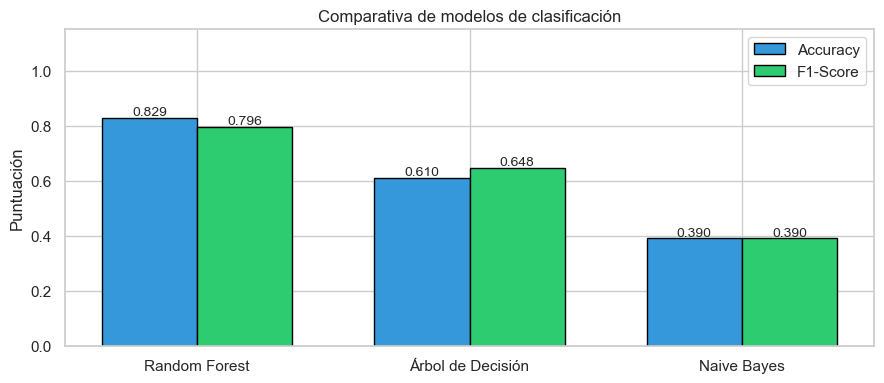

In [ ]:
resultados = pd.DataFrame({
    'Modelo': ['Árbol de Decisión', 'Naive Bayes', 'Random Forest'],
    'Accuracy': [acc_arbol, acc_nb, acc_rf],
    'F1-Score (weighted)': [f1_arbol, f1_nb, f1_rf],
})
resultados = resultados.sort_values('F1-Score (weighted)', ascending=False).reset_index(drop=True)
display(resultados.style.format({'Accuracy': '{:.4f}', 'F1-Score (weighted)': '{:.4f}'}))

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(resultados))
width = 0.35
bars1 = ax.bar(x - width/2, resultados['Accuracy'], width, label='Accuracy', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, resultados['F1-Score (weighted)'], width, label='F1-Score', color='#2ecc71', edgecolor='black')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(resultados['Modelo'])
ax.set_ylim(0, 1.15)
ax.set_ylabel('Puntuación')
ax.set_title('Comparativa de modelos de clasificación')
ax.legend()
plt.tight_layout()
plt.show()

### 📊 Interpretación — Comparativa de modelos

La tabla y la gráfica confirman de forma clara el ranking de desempeño:

| Modelo | Accuracy | F1-Score (weighted) |
|---|---|---|
| **Random Forest** | **0.8293** | **0.7965** |
| Árbol de Decisión | 0.6098 | 0.6479 |
| Naive Bayes | 0.3902 | 0.3902 |

**Random Forest supera a los otros modelos en ambas métricas**, con una ventaja de más de 20 puntos porcentuales sobre el Árbol de Decisión y de más de 40 puntos sobre Naive Bayes. La brecha entre Accuracy y F1-Score en Random Forest (82.9% vs 79.7%) refleja el impacto del desbalance de clases: el modelo es muy preciso para la clase mayoritaria, pero aún tiene margen de mejora en la detección de casos no resueltos.

### 7.2 Importancia de variables (Random Forest)

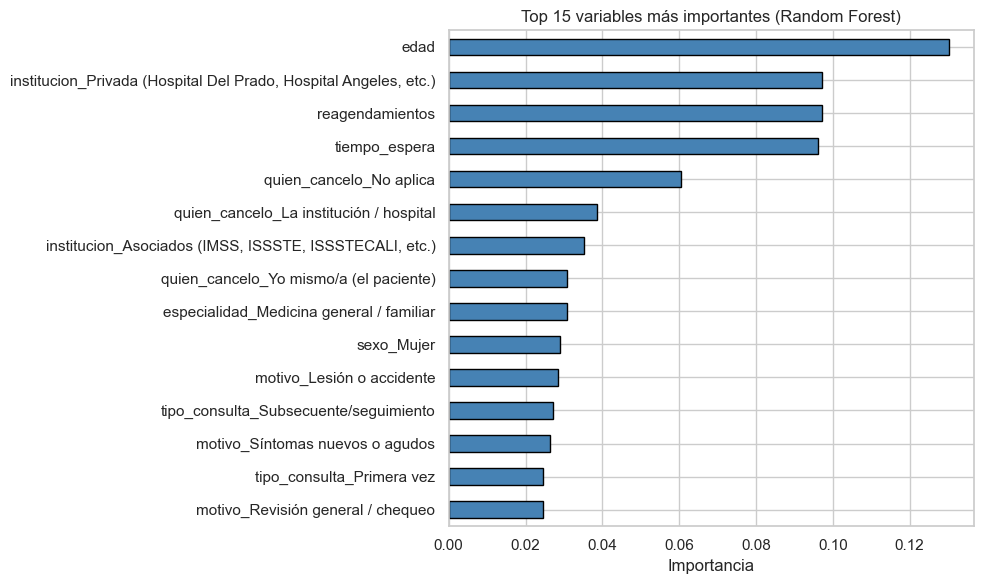

In [ ]:
importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns)
top15 = importancias.nlargest(15).sort_values()

top15.plot(kind='barh', color='steelblue', edgecolor='black', figsize=(10, 6))
plt.title('Top 15 variables más importantes (Random Forest)')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

### 📊 Interpretación — Importancia de variables (Random Forest)

El análisis de importancia de variables revela los factores que el modelo considera más informativos para predecir si un problema de salud fue resuelto:

1. **`edad`** es la variable más importante, lo que sugiere que la edad del paciente tiene una influencia significativa en el resultado, posiblemente porque condiciona el tipo de padecimiento y la velocidad de recuperación.
2. **`institucion_Privada`** y **`reagendamientos`** ocupan el segundo y tercer lugar, confirmando que el tipo de institución y la cantidad de citas canceladas son factores estructurales críticos del sistema de salud.
3. **`tiempo_espera`** es la cuarta variable más relevante, coherente con los hallazgos del análisis exploratorio de la sección 4.
4. Las variables relacionadas con **quién cancela la cita** (`quien_cancelo_No aplica`, `quien_cancelo_La institución`) también aparecen en el top, lo que refuerza la hipótesis de que las cancelaciones institucionales tienen un impacto negativo en el desenlace del paciente.

---
## 8. Conclusiones

### Hallazgos principales

1. La institución es el factor estructural más determinante del sistema de salud en Tijuana.
Las instituciones asociadas (IMSS, ISSSTE, ISSSTECALI) concentran los tiempos de espera más críticos: el 30.7% de sus usuarios espera más de un mes antes de ser atendido, frente a solo el 8.9% en instituciones privadas. Esta brecha no se limita al tiempo de espera: los desenlaces graves ocurren en el 26% de los casos en instituciones públicas, contra el 10.7% en hospitales privados. Este contraste evidencia que el tipo de institución no es simplemente una variable de control, sino un predictor central del resultado de salud del paciente, posiblemente reflejando diferencias en capacidad operativa, saturación de demanda y disponibilidad de especialistas.

2. El tiempo de espera influye en el resultado de salud, pero la relación no es lineal.
Contrario a lo que podría esperarse, los pacientes con esperas intermedias (3 a 6 meses) presentaron la tasa más baja de problema resuelto, superando incluso a quienes esperaron más de 6 meses. Esto sugiere que existe un umbral crítico de espera, a partir del cual el deterioro es más pronunciado, y también apunta a que factores como el tipo de padecimiento, la especialidad requerida o el número de reagendamientos pueden moderar esta relación. En patologías crónicas o progresivas, una espera de ese rango puede representar la ventana donde la condición escapa a un tratamiento efectivo temprano.

3. El número de reagendamientos es un indicador de riesgo subestimado.
Los datos muestran que los pacientes con 3 o más reagendamientos tienen desenlaces desfavorables con mayor frecuencia. Cada reagendamiento no solo retrasa la atención, sino que puede desincentivar la búsqueda de tratamiento y aumentar la carga emocional y económica del paciente. Quien cancela también importa: los casos en que la institución cancela la cita tienden a asociarse con peores resultados que cuando es el propio paciente quien reagenda, lo que señala problemas operativos internos del sistema de salud.

4. Random Forest superó a los otros dos modelos de forma consistente.
Con un Accuracy de 82.9% y un F1-Score ponderado de 79.6%, Random Forest fue claramente el mejor clasificador entre los tres evaluados. El Árbol de Decisión obtuvo resultados moderados (Accuracy 61.0%, F1 64.8%), mientras que Naive Bayes fue el de peor desempeño (Accuracy 39.0%, F1 39.0%), con una tendencia a clasificar casi todos los casos como "Sí resuelto", ignorando prácticamente la clase minoritaria. Este comportamiento de Naive Bayes es consistente con su supuesto de independencia entre variables, que claramente no se cumple en este dataset donde la institución, el tiempo de espera y el desenlace están correlacionados.

5. El desbalance de clases es un reto metodológico real en este tipo de estudios.
Solo el 15.5% de los registros corresponde a problema_resuelto = 0 (caso no resuelto), lo que crea un riesgo de modelos sesgados hacia la clase mayoritaria. El uso de class_weight='balanced' en los modelos de árbol mitigó parcialmente este efecto, pero el F1-Score de la clase minoritaria en Random Forest (0.36) indica que el modelo aún tiene dificultades para identificar correctamente los casos no resueltos. En contextos clínicos, estos son precisamente los casos de mayor urgencia; un falso negativo (clasificar como "resuelto" a alguien cuyo problema no lo está) tiene consecuencias más graves que un falso positivo.

6. El sesgo demográfico de la muestra limita la generalización de los modelos.
El 77% de los encuestados tiene entre 18 y 29 años, consecuencia directa de la difusión universitaria del formulario. La mediana de edad es 23 años, con un primer cuartil en 21 y un tercer cuartil en 26.5. Los adultos mayores —quienes son los usuarios más frecuentes y vulnerables del sistema de salud— están significativamente subrepresentados. Esto implica que los patrones aprendidos por los modelos reflejan principalmente la experiencia de adultos jóvenes, y no deben extrapolarse a poblaciones de mayor edad sin validación adicional.

### Limitaciones
La muestra de 201 registros es pequeña para entrenar modelos robustos de clasificación, especialmente con 42 variables tras la codificación. La recolección mediante formulario autoadministrado introduce sesgo de respuesta: es más probable que respondan quienes tuvieron experiencias memorables (muy buenas o muy malas), lo que puede distorsionar la distribución de desenlaces. Adicionalmente, el diagnóstico y el motivo de consulta fueron capturados como texto libre y luego normalizados manualmente, lo que introduce cierta ambigüedad en categorías limítrofes. Finalmente, la variable tiempo_espera_meses presentó 199 valores nulos de 207 registros, lo que la hizo prácticamente inutilizable como variable cuantitativa continua.

### Trabajos futuros
Para consolidar y extender estos hallazgos se recomienda ampliar la muestra con representación equilibrada por grupos de edad, especialmente adultos mayores de 40 años, mediante convenios con clínicas comunitarias o centros de salud del IMSS. Aplicar técnicas de sobremuestreo sintético como SMOTE sobre la clase minoritaria podría mejorar notablemente el recall del modelo para casos no resueltos. Incorporar datos oficiales del IMSS e ISSSTE (tiempos de espera reales por clínica, tasa de reagendamientos institucionales) permitiría una validación externa más rigurosa. A nivel metodológico, explorar modelos de ensamble más avanzados como Gradient Boosting o XGBoost, junto con validación cruzada estratificada, daría estimaciones más confiables del desempeño real. Finalmente, un análisis de supervivencia (time-to-event) podría modelar de forma más adecuada la relación entre tiempo de espera y probabilidad de resolución, capturando la no linealidad observada en los datos.